In [1]:
import pandas as pd
import os.path as op
import platform
import os
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin

In [2]:
if platform.system() == "Windows":
    wanted_dir = "/data/sourcedata/behavior/modified_files"
else:
    wanted_dir = "/Volumes/SDrive/data/sourcedata/behavior/modified_files"

files = [os.path.join(root, name) for root, dirs, files in os.walk(wanted_dir) for name in files if name.endswith('savedValues.csv')]

files = files[:-1]
files.remove(files[15])
files


['/Volumes/SDrive/data/sourcedata/behavior/modified_files/modified_participant01_savedValues.csv',
 '/Volumes/SDrive/data/sourcedata/behavior/modified_files/modified_participant02_savedValues.csv',
 '/Volumes/SDrive/data/sourcedata/behavior/modified_files/modified_participant03_savedValues.csv',
 '/Volumes/SDrive/data/sourcedata/behavior/modified_files/modified_participant04_savedValues.csv',
 '/Volumes/SDrive/data/sourcedata/behavior/modified_files/modified_participant05_savedValues.csv',
 '/Volumes/SDrive/data/sourcedata/behavior/modified_files/modified_participant06_savedValues.csv',
 '/Volumes/SDrive/data/sourcedata/behavior/modified_files/modified_participant07_savedValues.csv',
 '/Volumes/SDrive/data/sourcedata/behavior/modified_files/modified_participant08_savedValues.csv',
 '/Volumes/SDrive/data/sourcedata/behavior/modified_files/modified_participant09_savedValues.csv',
 '/Volumes/SDrive/data/sourcedata/behavior/modified_files/modified_participant10_savedValues.csv',
 '/Volumes

In [3]:
subjects = [1, 59]
# for i in range(len(files)):
#     subjects.append(int(files[i][-18:-16]))
    
data_folder = '/Volumes/SDrive/data/'
subjects

[1, 59]

In [4]:
df = []

for subject in subjects:
    d = pd.read_csv(op.join(data_folder, 'sourcedata', 'behavior', 'modified_files', f'modified_participant{subject:02d}_savedValues.csv'))

    df.append(d.set_index(['runNumber', 'trialNumber']))

df = pd.concat(df, keys=subjects, names=['subject'])

In [5]:
spes = []

for subject in subjects:
    # print(subject)

    try:
        spe = loadmat(f'/Volumes/SDrive/data/fittedParameters/sub-{subject:02d}/spe.mat')['spe']

        spe = pd.DataFrame(spe, columns=pd.Index(np.arange(1, 61), name='trialNumber'), index=pd.Index(np.arange(1, 7), name='runNumber'))

        spe = spe.stack().to_frame('spe')

        spes.append(spe)

    except Exception as e:
        subjects.pop(subjects.index(subject))
        print(f'There was a problem with subject {subject}:\n{e}')

spes = pd.concat(spes, keys=subjects, names=['subject'])
spes

spe
subject runNumber trialNumber          
1       1         1            2.197225
                  2            2.302585
                  3            2.397895
                  4            2.484907
                  5            2.564949
...                                 ...
59      6         56           3.060271
                  57           1.871802
                  58           2.397895
                  59           2.258782
                  60           2.273598

[720 rows x 1 columns]

In [6]:
df = df.join(spes)

In [7]:
list(df.columns)

['visualSet',
 'audioPair_1',
 'audioPair_2',
 'audioPair_3',
 'tactilePair_1',
 'tactilePair_2',
 'tactilePair_3',
 'visual',
 'audio',
 'tactile',
 'combinationConditionalProbability',
 'correctResponse',
 'chosenKey',
 'accurate',
 'reward',
 'runStartTime',
 'trialStartTime',
 'stimulusOnsetTime',
 'stimulusOffsetTime',
 'responsePressTime',
 'responseTime',
 'responseTimeOver',
 'feedbackOnsetTime',
 'responseTimeThreshold',
 'totalAccuracy',
 'totalErrorRate',
 'accurateIndex',
 'inaccurateIndex',
 'feedbackAccuracy',
 'feedbackOffsetTime',
 'action',
 'stimulusPair',
 'spe']

0.06697775572948196


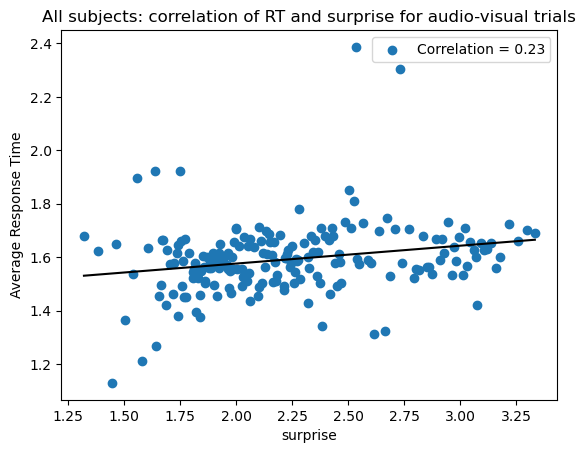

In [8]:

audio_df = df.dropna(subset=['audio'])


avg_response_time = audio_df.groupby('spe')['responseTime'].mean()

plt.scatter(avg_response_time.index, avg_response_time.values, label=f'Correlation = {np.round(np.corrcoef(avg_response_time.index, avg_response_time.values)[0,1], 2)}')

plt.legend()

m, b = np.polyfit(avg_response_time.index, avg_response_time.values, 1)
plt.plot(avg_response_time.index, m*avg_response_time.index+b, c = "k")


print(m)

plt.xlabel('surprise')
plt.ylabel('Average Response Time')
plt.title("All subjects: correlation of RT and surprise for audio-visual trials")
plt.show()

In [9]:
pingouin.rm_corr(audio_df.reset_index(), x='spe', y='responseTime', subject='subject')

,r,dof,pval,CI95%,power
rm_corr,0.078338,10835,3.169375e-16,"[0.06, 0.1]",1.0


0.0204828471801966


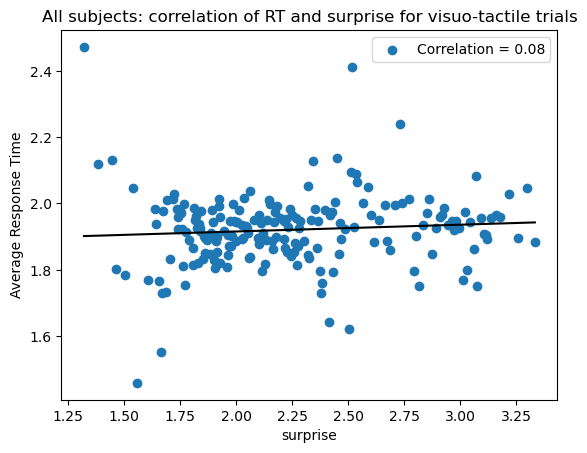

In [10]:

tactile_df = df.dropna(subset=['tactile'])


avg_response_time = tactile_df.groupby('spe')['responseTime'].mean()

plt.scatter(avg_response_time.index, avg_response_time.values, label=f'Correlation = {np.round(np.corrcoef(avg_response_time.index, avg_response_time.values)[0,1], 2)}')

plt.legend()

m, b = np.polyfit(avg_response_time.index, avg_response_time.values, 1)
plt.plot(avg_response_time.index, m*avg_response_time.index+b, c = "k")

print(m) 

plt.xlabel('surprise')
plt.ylabel('Average Response Time')
plt.title("All subjects: correlation of RT and surprise for visuo-tactile trials")
plt.show()

In [11]:
pingouin.rm_corr(tactile_df.reset_index(), x='spe', y='responseTime', subject='subject')

,r,dof,pval,CI95%,power
rm_corr,0.031981,10793,0.00089,"[0.01, 0.05]",0.913654


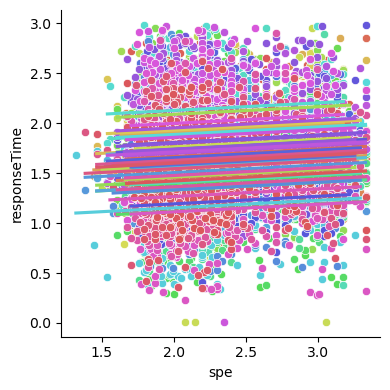

In [12]:
pingouin.plot_rm_corr(audio_df.reset_index(), x='spe', y='responseTime', subject='subject')

Text(-11.055555555555555, 0.5, 'r')

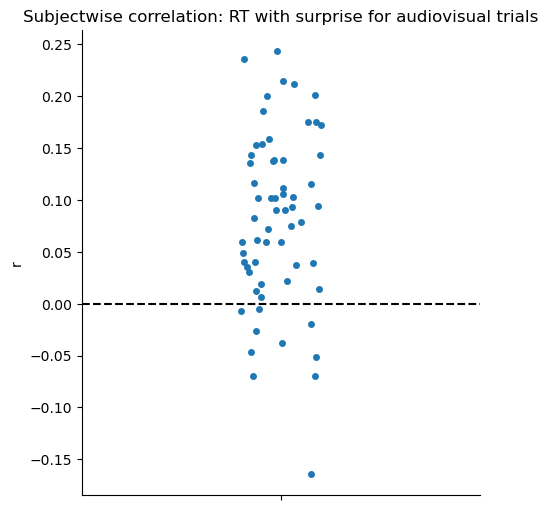

In [13]:

r_a = audio_df.groupby('subject').apply(lambda d: pingouin.corr(d['spe'], d['responseTime']))

sns.catplot(r_a, y='r')
plt.axhline(0.0, c='k' ,ls='--')
plt.title("Subjectwise correlation: RT with surprise for audiovisual trials")
plt.ylabel("r")

Text(0.5, 1.0, 'Subjectwise correlation: RT with surprise for visuotactile trials')

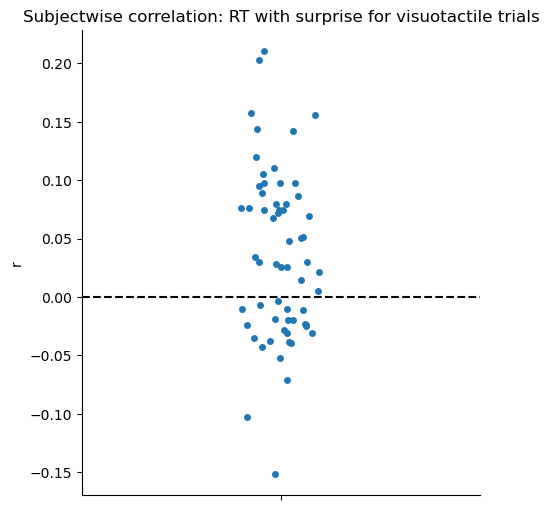

In [14]:

r_t = tactile_df.groupby('subject').apply(lambda d: pingouin.corr(d['spe'], d['responseTime']))

sns.catplot(r_t, y='r')
plt.axhline(0.0, c='k' ,ls='--')
plt.title("Subjectwise correlation: RT with surprise for visuotactile trials")

In [15]:
df['audio_indicator'] = df['audio'].notna().astype(int)
df

visualSet  audioPair_1  audioPair_2  \
subject runNumber trialNumber                                        
1       1         1                    0            1            0   
                  2                    0            1            0   
                  3                    0            1            0   
                  4                    0            1            0   
                  5                    0            1            0   
...                                  ...          ...          ...   
64      6         56                   5            2            0   
                  57                   5            2            0   
                  58                   5            2            0   
                  59                   5            2            0   
                  60                   5            2            0   

                               audioPair_3  tactilePair_1  tactilePair_2  \
subject runNumber trialNumber                                              
1       1         1                      2              0              1   
                  2                      2              0              1   
                  3                      2              0              1   
                  4                      2              0              1   
                  5                      2              0              1   
...                                    ...            ...            ...   
64      6         56                     1              1              2   
                  57                     1              1              2   
                  58                     1              1              2   
                  59                     1              1              2   
                  60                     1              1              2   

                               tactilePair_3  visual  audio  tactile  ...  \
subject runNumber trialNumber                                         ...   
1       1         1                        2       0    NaN      2.0  ...   
                  2                        2       1    NaN      1.0  ...   
                  3                        2       2    NaN      2.0  ...   
                  4                        2       0    NaN      0.0  ...   
                  5                        2       2    NaN      1.0  ...   
...                                      ...     ...    ...      ...  ...   
64      6         56                       0       0    1.0      NaN  ...   
                  57                       0       1    0.0      NaN  ...   
                  58                       0       2    2.0      NaN  ...   
                  59                       0       1    1.0      NaN  ...   
                  60                       0       2    2.0      NaN  ...   

                               totalAccuracy  totalErrorRate accurateIndex  \
subject runNumber trialNumber                                                
1       1         1                 0.000000        1.000000             1   
                  2                 0.000000        1.000000             1   
                  3                 0.333333        0.666667             1   
                  4                 0.250000        0.750000             2   
                  5                 0.200000        0.800000             2   
...                                      ...             ...           ...   
64      6         56                0.892857        0.107143            50   
                  57                0.894737        0.105263            51   
                  58                0.896552        0.103448            52   
                  59                0.898305        0.101695            53   
                  60                0.900000        0.100000            54   

                               inaccurateIndex  feedbackAccuracy  \
subject runNumber trialNumber                 

In [24]:
df['responseTime'].isnull().sum()

208

In [169]:
data=df.dropna(subset=['responseTime'])

df.loc[:,"audio_indicator"] = df.loc[:,"audio_indicator"] - df.loc[:,"audio_indicator"].mean()

In [170]:
import statsmodels.formula.api as sm

# df = df.reset_index()

# Create the formula for the mixed-effects model
formula = 'responseTime ~ spe + audio_indicator + spe:audio_indicator'

# Fit the mixed-effects model using the MixedLM class
model = sm.mixedlm(formula, data=df.dropna(subset=['responseTime']).reset_index(), groups='subject', re_formula='~audio_indicator')

model_fit = model.fit(method='bfgs')

# Print the summary of the model
print(model_fit.summary())

                  Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      responseTime
No. Observations:      21752        Method:                  REML        
No. Groups:            61           Scale:                   0.1374      
Min. group size:       343          Log-Likelihood:          -9519.7109  
Max. group size:       360          Converged:               Yes         
Mean group size:       356.6                                             
-------------------------------------------------------------------------
                              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                      1.654    0.031  53.746 0.000  1.593  1.714
spe                            0.053    0.006   8.196 0.000  0.040  0.065
audio_indicator               -0.414    0.036 -11.559 0.000 -0.484 -0.344
spe:audio_indicator            0.046    0.013   3.587 0.

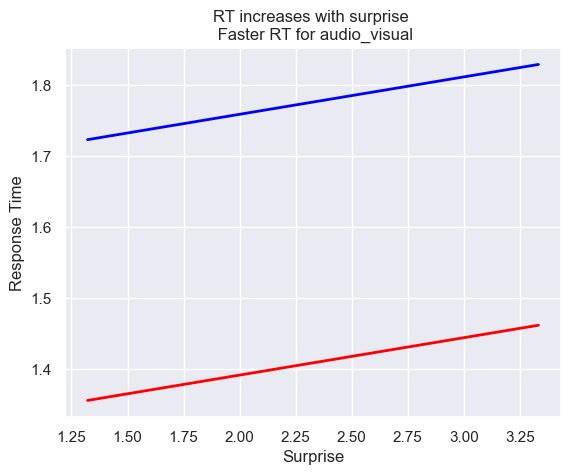

In [171]:
import numpy as np
import matplotlib.pyplot as plt
sns.set()
# Generate data for line plots
x0 = np.linspace(min(df[df['audio_indicator']==-0.5]['spe']), max(df[df['audio_indicator']==-0.5]['spe']), 100)
y0 = model_fit.params['spe'] * x0 + model_fit.params['Intercept']
x1 = np.linspace(min(df[df['audio_indicator']==0.5]['spe']), max(df[df['audio_indicator']==0.5]['spe']), 100)
y1 = (model_fit.params['spe'] * x1 + model_fit.params['audio_indicator']+ model_fit.params['spe:audio_indicator'] + model_fit.params['Intercept'])

# Create figure and axis objects
fig, ax = plt.subplots()

# Plot lines for correlations between spe and responseTime
ax.plot(x0, y0, color='blue', alpha=1., linewidth=2, label='tactile runs')
ax.plot(x1, y1, color='red', alpha=1., linewidth=2, label='audio runs')



# # Overlay scatter plots for two audio_indicator values
# ax.scatter(df[df['audio_indicator']==0]['spe'], df[df['audio_indicator']==0]['responseTime'], color='blue', alpha=0.04, s=1)
# ax.scatter(df[df['audio_indicator']==1]['spe'], df[df['audio_indicator']==1]['responseTime'], color='red', alpha=0.04, s=1)

# Set axis labels and legend
ax.set_xlabel('Surprise')
ax.set_ylabel('Response Time')

plt.title("RT increases with surprise \n Faster RT for audio_visual")

# Show plot
plt.show()

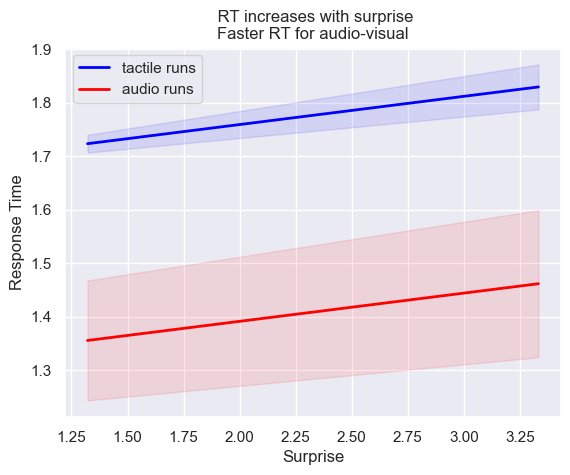

In [174]:
import numpy as np
import matplotlib.pyplot as plt
sns.set()
# Generate data for line plots
x0 = np.linspace(min(df[df['audio_indicator']==-0.5]['spe']), max(df[df['audio_indicator']==-0.5]['spe']), 100)
y0 = model_fit.params['spe'] * x0 + model_fit.params['Intercept']
ci0 = model_fit.conf_int().loc['spe']
y0_upper = ci0[1] * x0 + model_fit.params['Intercept']
y0_lower = ci0[0] * x0 + model_fit.params['Intercept']

x1 = np.linspace(min(df[df['audio_indicator']==0.5]['spe']), max(df[df['audio_indicator']==0.5]['spe']), 100)
y1 = (model_fit.params['spe'] * x1 + model_fit.params['audio_indicator']
      + model_fit.params['spe:audio_indicator'] + model_fit.params['Intercept'])
ci1 = model_fit.conf_int().loc[['spe', 'audio_indicator', 'spe:audio_indicator']]
y1_upper = (ci1.loc['spe', 1] * x1 + ci1.loc['audio_indicator', 1]
            + ci1.loc['spe:audio_indicator', 1] + model_fit.params['Intercept'])
y1_lower = (ci1.loc['spe', 0] * x1 + ci1.loc['audio_indicator', 0]
            + ci1.loc['spe:audio_indicator', 0] + model_fit.params['Intercept'])

# Create figure and axis objects
fig, ax = plt.subplots()

# Plot lines and confidence intervals for correlations between spe and responseTime
ax.plot(x0, y0, color='blue', alpha=1., linewidth=2, label='tactile runs')
ax.fill_between(x0, y0_upper, y0_lower, color='blue', alpha=.1)
ax.plot(x1, y1, color='red', alpha=1., linewidth=2, label='audio runs')
ax.fill_between(x1, y1_upper, y1_lower, color='red', alpha=.1)

# Overlay scatter plots for two audio_indicator values
# ax.scatter(df[df['audio_indicator']==0]['spe'], df[df['audio_indicator']==0]['responseTime'], color='blue', alpha=0.04, s=1)
# ax.scatter(df[df['audio_indicator']==1]['spe'], df[df['audio_indicator']==1]['responseTime'], color='red', alpha=0.04, s=1)

# Set axis labels and legend
ax.set_xlabel('Surprise')
ax.set_ylabel('Response Time')
plt.title(" RT increases with surprise\nFaster RT for audio-visual")
ax.legend()

# Show plot
plt.show()
